# Analisis EDA

## Carga de los datos

In [1]:
%cd ..

c:\Users\juanw\Desktop\garbage-classification


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from PIL import Image
from src.carga import cargar_datos

In [3]:
root = 'data/Garbage-classification/Garbage-classification/'
df = cargar_datos(root)
df.head()

,x,y
2255,data/Garbage-classification/Garbage-classifica...,plastic
1820,data/Garbage-classification/Garbage-classifica...,paper
1852,data/Garbage-classification/Garbage-classifica...,paper
513,data/Garbage-classification/Garbage-classifica...,glass
1941,data/Garbage-classification/Garbage-classifica...,plastic


In [7]:
print('Clases únicas:', df['y'].unique())


Clases únicas: <StringArray>
['plastic', 'paper', 'glass', 'metal', 'cardboard', 'trash']
Length: 6, dtype: str


## Visualización de Imagenes

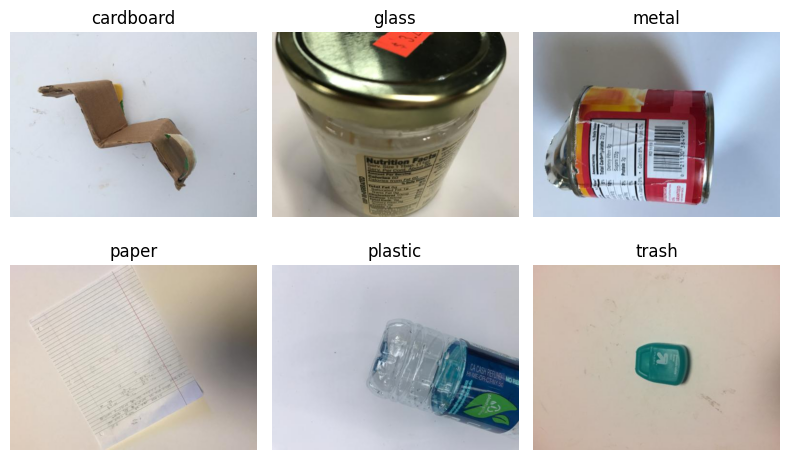

In [17]:
clases = sorted(df['y'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(8, 5))
axes = np.array(axes).reshape(-1)

for idx, clase in enumerate(clases):
    ruta_img = df.loc[df['y'] == clase, 'x'].iloc[0]
    img = Image.open(ruta_img).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(clase)
    axes[idx].axis('off')

for ax in axes[3:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Info DataFrame

In [18]:
#Numero de clases
print('Número de clases:', df['y'].unique())

Número de clases: <StringArray>
['plastic', 'paper', 'glass', 'metal', 'cardboard', 'trash']
Length: 6, dtype: str


Número de imágenes por clase:
y
cardboard    403
glass        501
metal        410
paper        594
plastic      482
trash        137
Name: count, dtype: int64


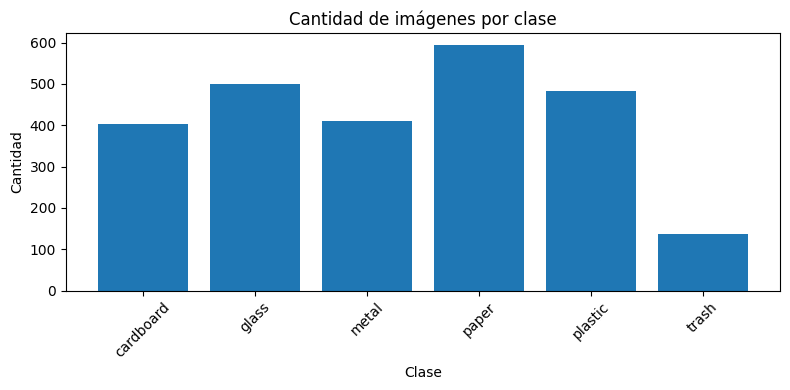

In [20]:
# Numero de imagenes por clase + grafico de barras
conteo = df['y'].value_counts().sort_index()
print('Número de imágenes por clase:')
print(conteo)

plt.figure(figsize=(8, 4))
plt.bar(conteo.index, conteo.values)
plt.title('Cantidad de imágenes por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
#Dimensiones de las imágenes
img = Image.open(df['x'].iloc[0])
img_array = np.array(img)
print('Dimensiones del array de la imagen:', img_array.shape)

Dimensiones del array de la imagen: (384, 512, 3)


In [22]:
#Ver si hay nulos 
print("Número de valores nulos por columna:")
print(df.isnull().sum())

Número de valores nulos por columna:
x    0
y    0
dtype: int64
